
Baseline Monte Carlo reductions (mean ± SD):
Peak reduction (%):  16.29 ± 6.38
Total reduction (%): 25.65 ± 1.19


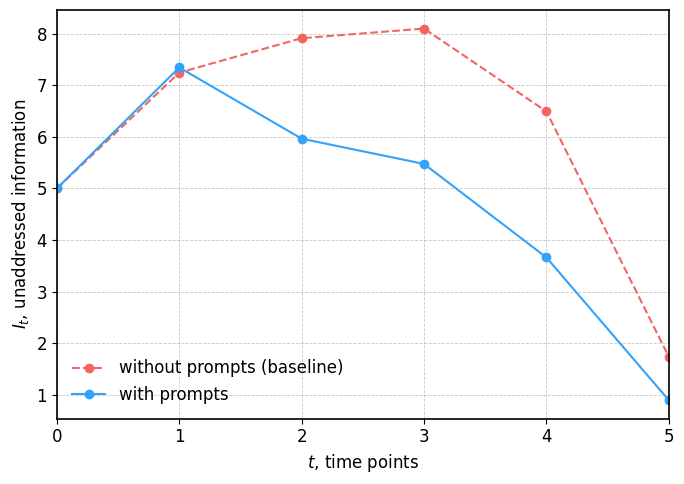

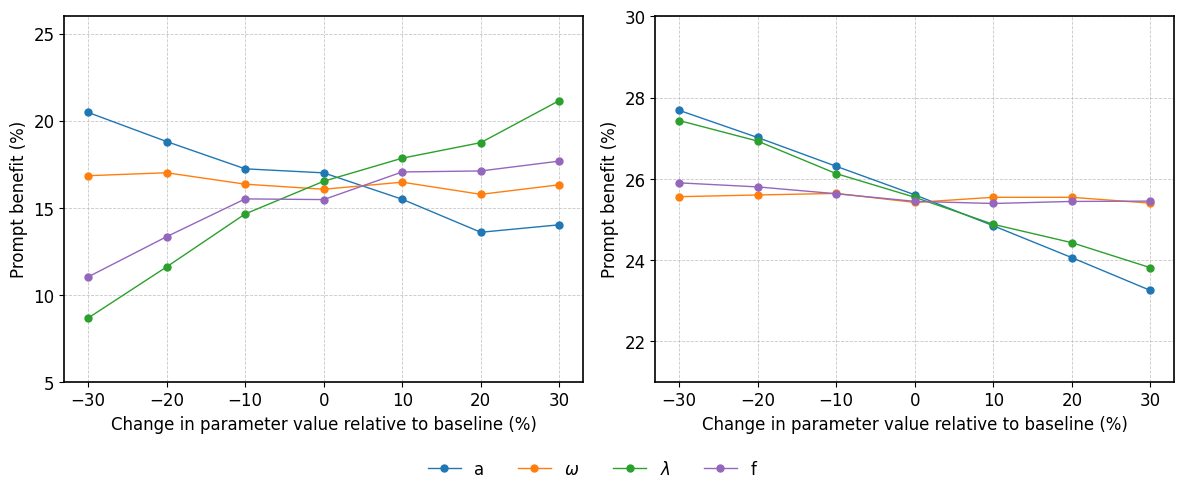


Saved outputs (minimal dataset):
 - model_inputs_scalar.csv
 - prompt_inputs_b_tj.csv
 - prompt_inputs_c_tj.csv
 - baseline_trajectories.csv
 - baseline_mc_draws.csv
 - sensitivity_curve_points.csv
 - sensitivity_mc_draws.csv

Saved figures:
 - unaddressed_information_trajectories.tiff
 - unaddressed_information_OAT_sensitivity.tiff


In [24]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# EDIT HERE: baseline parameters
# ============================================================
n = 5
dt = 1.0
I0 = 5.0
BASE = {"a": 0.50, "w": 0.15, "lam": 1.2, "f": 15.0}

# One-at-a-time sensitivity perturbations (% change from baseline)
PCT_OFFSETS = np.array([-30, -20, -10, 0, 10, 20, 30], dtype=float)
MULT = 1.0 + PCT_OFFSETS / 100.0

# Reproducibility settings
USE_NOISE = True
SEED_TRAJECTORY = 42
SEED_MC = 123
MC_REPS_BASELINE = 300
MC_REPS_SENS = 300

# Output file names
FIG_BASELINE = "unaddressed_information_trajectories"
FIG_SENS = "unaddressed_information_OAT_sensitivity"

# Data exports (minimal dataset)
CSV_SCALARS = "model_inputs_scalar.csv"
CSV_B = "prompt_inputs_b_tj.csv"
CSV_C = "prompt_inputs_c_tj.csv"
CSV_BASELINE_TRAJ = "baseline_trajectories.csv"
CSV_BASELINE_DRAWS = "baseline_mc_draws.csv"
CSV_SENS_POINTS = "sensitivity_curve_points.csv"
CSV_SENS_DRAWS = "sensitivity_mc_draws.csv"

# Figure export settings
DPI = 600

# ============================================================
# EDIT HERE: prompt parameters (elicited from case study)
# rows: t=1..5, cols: j=1..8
# ============================================================
b_tj = np.array([
    [1,1,1,1,1,0,0,0],
    [1,1,0,1,1,1,0,0],
    [1,1,1,1,0,1,1,0],
    [1,0,1,1,0,1,1,1],
    [0,0,1,1,0,1,1,1],
], dtype=int)

c_tj = np.array([
    [-0.09,-0.07, 0.05, 0.04, 0.05, 0.0, 0.0, 0.0],
    [ 0.06, 0.06, 0.0, 0.05, 0.04, 0.06, 0.0, 0.0],
    [ 0.05, 0.06, 0.05, 0.07, 0.0, 0.06,-0.05, 0.0],
    [ 0.08, 0.0, 0.07, 0.05, 0.0, 0.08,-0.03,-0.04],
    [ 0.0, 0.0, 0.06, 0.06, 0.0, 0.07,-0.05,-0.07],
], dtype=float)

assert b_tj.shape == c_tj.shape, "b_tj and c_tj must have the same shape"
assert b_tj.shape[0] == n, "Number of rows in prompt arrays must equal n"

# Convert to b_{j,t}, c_{j,t} with shape (k, n)
b_jt = b_tj.T
c_jt = c_tj.T

# ============================================================
# Plot formatting (minimal)
# ============================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2
})

# ============================================================
# Plot colors (EDIT HERE)
# ============================================================
COLORS = {
    "baseline": "#F16663",   # without prompts (baseline)
    "prompts":  "#33A2FA",   # with prompts
    "a":        "#1F77B4",   # processing rate
    "w":        "#FF7F0E",   # noise coefficient
    "lam":      "#2CA02C",   # arrival rate
    "f":        "#9467BD",   # information scale
}

# ============================================================
# Match notations (EDIT HERE)
# ============================================================

LABELS = {
    "a": "a",
    "w": r"$\omega$",
    "lam": r"$\lambda$",
    "f": "f"
}

# ============================================================
# Functions
# ============================================================
def poisson_pmf(lam: float, t: int) -> float:
    return (lam**t) * math.exp(-lam) / math.factorial(t)

def arrivals(lam: float, f: float) -> np.ndarray:
    return np.array([f * poisson_pmf(lam, t) * dt for t in range(n)], dtype=float)

def simulate(use_prompts: bool, params: dict, eps: np.ndarray) -> np.ndarray:
    """
      I_{t+1} = max( I_t + N_t + ((w*eps_t - a - sum_j b_{j,t} c_{j,t}) * dt) * I_t , 0 )
    """
    a = params["a"]; w = params["w"]; lam = params["lam"]; f = params["f"]
    N = arrivals(lam, f)

    I = np.zeros(n + 1, dtype=float)
    I[0] = I0

    for t in range(n):
        prompt_frac = float(np.sum(b_jt[:, t] * c_jt[:, t])) if use_prompts else 0.0
        drift = ((w * eps[t]) - a - prompt_frac) * dt
        I[t + 1] = max(I[t] + N[t] + drift * I[t], 0.0)

    return I

def metric_peak(I: np.ndarray) -> float:
    return float(np.max(I))

def metric_total(I: np.ndarray) -> float:
    return float(np.sum(I[1:]) * dt)

def percent_reduction(Y_base: float, Y_with: float) -> float:
    return 100.0 * (Y_base - Y_with) / max(Y_base, 1e-12)

def mean_sd(x: np.ndarray):
    return float(np.mean(x)), float(np.std(x, ddof=1))

def save_tiff(basepath: str, dpi: int = DPI):
    plt.savefig(
        basepath + ".tiff",
        dpi=dpi,
        pil_kwargs={"compression": "tiff_lzw"}
    )

# ============================================================
# Export inputs (minimal dataset metadata)
# ============================================================
with open(CSV_SCALARS, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["n", n])
    writer.writerow(["dt", dt])
    writer.writerow(["I0", I0])
    writer.writerow(["USE_NOISE", USE_NOISE])
    writer.writerow(["SEED_TRAJECTORY", SEED_TRAJECTORY])
    writer.writerow(["SEED_MC", SEED_MC])
    writer.writerow(["MC_REPS_BASELINE", MC_REPS_BASELINE])
    writer.writerow(["MC_REPS_SENS", MC_REPS_SENS])
    for k in ["a", "w", "lam", "f"]:
        writer.writerow([k, BASE[k]])
    writer.writerow(["PCT_OFFSETS", ",".join(str(int(x)) for x in PCT_OFFSETS)])

with open(CSV_B, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["t\\j"] + [f"j{j+1}" for j in range(b_tj.shape[1])])
    for t in range(b_tj.shape[0]):
        writer.writerow([f"t{t+1}"] + list(b_tj[t, :]))

with open(CSV_C, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["t\\j"] + [f"j{j+1}" for j in range(c_tj.shape[1])])
    for t in range(c_tj.shape[0]):
        writer.writerow([f"t{t+1}"] + list(c_tj[t, :]))

# ============================================================
# Baseline Monte Carlo: save replicate-level reductions (raw values)
# ============================================================
def baseline_mc_draws(reps: int, seed: int):
    rng = np.random.default_rng(seed)
    peak_red = np.zeros(reps, dtype=float)
    total_red = np.zeros(reps, dtype=float)

    for r in range(reps):
        eps = rng.normal(0.0, 1.0, size=n) if USE_NOISE else np.zeros(n, dtype=float)
        I_base = simulate(False, BASE, eps)
        I_with = simulate(True,  BASE, eps)

        peak_red[r] = percent_reduction(metric_peak(I_base), metric_peak(I_with))
        total_red[r] = percent_reduction(metric_total(I_base), metric_total(I_with))

    return peak_red, total_red

peak_red_draws, total_red_draws = baseline_mc_draws(MC_REPS_BASELINE, SEED_MC)
peak_mean, peak_sd = mean_sd(peak_red_draws)
total_mean, total_sd = mean_sd(total_red_draws)

with open(CSV_BASELINE_DRAWS, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["replicate", "peak_reduction_percent", "total_reduction_percent"])
    for r in range(MC_REPS_BASELINE):
        writer.writerow([r+1, f"{peak_red_draws[r]:.6f}", f"{total_red_draws[r]:.6f}"])

print("\nBaseline Monte Carlo reductions (mean ± SD):")
print(f"Peak reduction (%):  {peak_mean:.2f} ± {peak_sd:.2f}")
print(f"Total reduction (%): {total_mean:.2f} ± {total_sd:.2f}")

# ============================================================
# Baseline trajectory figure: save the values used to build the graph
# ============================================================
rng_traj = np.random.default_rng(SEED_TRAJECTORY)
eps_traj = rng_traj.normal(0.0, 1.0, size=n) if USE_NOISE else np.zeros(n, dtype=float)

I_base_traj = simulate(False, BASE, eps_traj)
I_with_traj = simulate(True,  BASE, eps_traj)

with open(CSV_BASELINE_TRAJ, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["t", "I_without_prompts", "I_with_prompts"])
    for t in range(n + 1):
        writer.writerow([t, f"{I_base_traj[t]:.6f}", f"{I_with_traj[t]:.6f}"])

steps = np.arange(n + 1)

plt.figure(figsize=(7, 5))

plt.plot(
    steps, I_base_traj,
    color=COLORS["baseline"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="without prompts (baseline)"
)

plt.plot(
    steps, I_with_traj,
    color=COLORS["prompts"],
    marker="o",
    linestyle="-",
    linewidth=1.5,
    label="with prompts"
)

plt.xlabel(r"$t$, time points")
plt.ylabel(r"$I_t$, unaddressed information")
plt.xticks(steps)
plt.xlim(0, n)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(loc="lower left", frameon=False)
plt.tight_layout()
save_tiff(FIG_BASELINE)
plt.show()

# ============================================================
# Sensitivity: save replicate-level values (raw) and curve points used for graphs
# ============================================================
def oat_sensitivity_draws(param_name: str, reps: int, seed: int):
    """
    Returns:
      - peak_draws[pct_index, rep]
      - total_draws[pct_index, rep]
      - peak_mean/sd vectors
      - total_mean/sd vectors
    """
    rng = np.random.default_rng(seed)

    peak_draws = np.zeros((len(MULT), reps), dtype=float)
    total_draws = np.zeros((len(MULT), reps), dtype=float)

    for i, mult in enumerate(MULT):
        params = BASE.copy()
        params[param_name] = BASE[param_name] * float(mult)

        for r in range(reps):
            eps = rng.normal(0.0, 1.0, size=n) if USE_NOISE else np.zeros(n, dtype=float)
            I_base = simulate(False, params, eps)
            I_with = simulate(True,  params, eps)

            peak_draws[i, r] = percent_reduction(metric_peak(I_base), metric_peak(I_with))
            total_draws[i, r] = percent_reduction(metric_total(I_base), metric_total(I_with))

    peak_means = np.array([mean_sd(peak_draws[i, :])[0] for i in range(len(MULT))])
    peak_sds   = np.array([mean_sd(peak_draws[i, :])[1] for i in range(len(MULT))])
    total_means = np.array([mean_sd(total_draws[i, :])[0] for i in range(len(MULT))])
    total_sds   = np.array([mean_sd(total_draws[i, :])[1] for i in range(len(MULT))])

    return peak_draws, total_draws, peak_means, peak_sds, total_means, total_sds

sens = {}
for p, sd in zip(["a", "w", "lam", "f"], [SEED_MC + 1, SEED_MC + 2, SEED_MC + 3, SEED_MC + 4]):
    sens[p] = oat_sensitivity_draws(p, MC_REPS_SENS, sd)

# Save sensitivity draws (raw values behind means/SDs)
with open(CSV_SENS_DRAWS, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["parameter", "pct_change", "replicate", "peak_benefit_percent", "total_benefit_percent"])
    for p in ["a", "w", "lam", "f"]:
        peak_draws, total_draws, _, _, _, _ = sens[p]
        for i, pct in enumerate(PCT_OFFSETS):
            for r in range(MC_REPS_SENS):
                writer.writerow([p, int(pct), r+1, f"{peak_draws[i, r]:.6f}", f"{total_draws[i, r]:.6f}"])

# Save curve points used for graphs
with open(CSV_SENS_POINTS, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["parameter", "pct_change",
                "peak_benefit_mean", "peak_benefit_sd",
                "total_benefit_mean", "total_benefit_sd"])
    for p in ["a", "w", "lam", "f"]:
        _, _, peak_m, peak_sd, total_m, total_sd = sens[p]
        for i, pct in enumerate(PCT_OFFSETS):
            writer.writerow([p, int(pct),
                        f"{peak_m[i]:.6f}", f"{peak_sd[i]:.6f}",
                        f"{total_m[i]:.6f}", f"{total_sd[i]:.6f}"])

# Plot sensitivity curves

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for p in ["a", "w", "lam", "f"]:
    _, _, peak_m, _, total_m, _ = sens[p]

    axes[0].plot(
        PCT_OFFSETS, peak_m,
        color=COLORS[p],
        marker="o",
        markersize=5,
        linewidth=1,
        label=LABELS[p]
    )

    axes[1].plot(
        PCT_OFFSETS, total_m,
        color=COLORS[p],
        marker="o",
        markersize=5,
        linewidth=1,
        label=LABELS[p]
    )

axes[0].set_xlabel("Change in parameter value relative to baseline (%)")
axes[0].set_ylabel("Prompt benefit (%)")
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

axes[1].set_xlabel("Change in parameter value relative to baseline (%)")
axes[1].set_ylabel("Prompt benefit (%)")
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

axes[0].set_ylim(5, 26)
axes[1].set_ylim(21, 30)

axes[0].yaxis.set_major_locator(MaxNLocator(5))
axes[1].yaxis.set_major_locator(MaxNLocator(5))

# axes[0].set_yticks(np.arange(6, int(axes[0].get_ylim()[1]) + 1, 3))
# axes[1].set_yticks(np.arange(6, int(axes[1].get_ylim()[1]) + 1, 3))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
save_tiff(FIG_SENS)
plt.show()

print("\nSaved outputs (minimal dataset):")
print(" -", CSV_SCALARS)
print(" -", CSV_B)
print(" -", CSV_C)
print(" -", CSV_BASELINE_TRAJ)
print(" -", CSV_BASELINE_DRAWS)
print(" -", CSV_SENS_POINTS)
print(" -", CSV_SENS_DRAWS)
print("\nSaved figures:")
print(" -", FIG_BASELINE + ".tiff")
print(" -", FIG_SENS + ".tiff")
